# Nobody told it what a noun is

This notebook goes with the post of the same name. It lets you run the experiment yourself.

**The claim.** A language model does not need to be taught word classes. Nouns, verbs, adjectives and adverbs appear
by themselves when a model learns to predict the next word.

**The test.** A very small model, with one attention head, reads four novels. Its only task is to predict the next
word. Nothing in the training mentions grammar. Afterwards we look at where the model put each word.

**The control.** The same model reads the same text, but with the words inside each sentence shuffled. If word
classes come from word order, they must not appear here.

**What you can do here.**

1. Look at the text and at the labels that are used only for the measurement.
2. Train the model in a short run (about 1 minute on a laptop).
3. Load the saved full run and the saved control (about 5 minutes each) and draw the figures.
4. Look up the nearest neighbours of any word.

The code is in `attn_emergence.py`. This notebook only calls it.

In [1]:
# Run this cell first. On Colab it gets the repository. On your own machine it does nothing.
import os, sys
if "google.colab" in sys.modules and not os.path.exists("attn_emergence.py"):
    !git clone -q https://github.com/vlrmzz/ai-claims-experiments
    %cd ai-claims-experiments/nobody-told-it-what-a-noun-is

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import attn_emergence as ae
import viz_emergence as viz

## 1. The text and the labels

The text is three novels by Jane Austen and *Alice's Adventures in Wonderland*. A separate program, a part-of-speech
tagger, gives each word a class. **The model never sees these labels.** They are used only afterwards, to measure
what the model learned.

The first time, this cell downloads the novels and the tagger (about 40 MB).

In [3]:
ids, vocab, content = ae.load(shuffle=False)

print(f"{len(ids):,} words of text, a vocabulary of {len(vocab):,}")
print(f"{len(content):,} frequent content words are measured\n")
for c, name in enumerate(ae.CLASSES):
    words = [w for w, _, k in content if k == c]
    print(f"{name:5s} {len(words):4d} words, for example: {', '.join(words[5:95:10])}")

393,787 words of text, a vocabulary of 3,110
1,320 frequent content words are measured

NOUN   616 words, for example: admiral, ah, appearance, aunt, bit, brother, case, charge, civility
VERB   409 words, for example: added, allowed, ashamed, attend, began, broken, catch, concerned, dancing
ADJ    184 words, for example: angry, certain, constant, disagreeable, eldest, fit, good, highest, intimate
ADV    111 words, for example: alone, close, equally, farther, here, lately, never, possibly, scarcely


## 2. A short run

This trains the model for 800 steps. The full run has 4,000.

Two numbers show whether word classes have appeared:

- **neighbours**: for each word, the share of its 10 nearest words that have the same class. The four numbers in
  brackets are nouns, verbs, adjectives and adverbs.
- **probe**: how often a simple linear classifier can read the class of a word from its position.

Before training, both numbers are at the level of chance.

In [4]:
short = ae.run(800, shuffle=False, save=False)

real text: 393,787 words, vocabulary 3,110, 1,320 content words, 419,622 parameters
chance: neighbours 34%, probe (always guess noun) 47%; classes NOUN 47% / VERB 31% / ADJ 14% / ADV 8%


step     0  loss  8.36  neighbours 34% (47% / 31% / 15% / 8%)  probe 41%


step   500  loss  4.92  neighbours 44% (57% / 42% / 23% / 12%)  probe 67%


step   800  loss  4.78  neighbours 51% (63% / 52% / 30% / 17%)  probe 74%


68 s


## 3. The full run

`run_real.npz` holds the full run of 4,000 steps.

Top row: the same words at four moments. The axes are fixed from the final state, so the movement that you see is
real. Bottom left: the loss, which is the only thing the training looks at. Bottom right: the two measures.

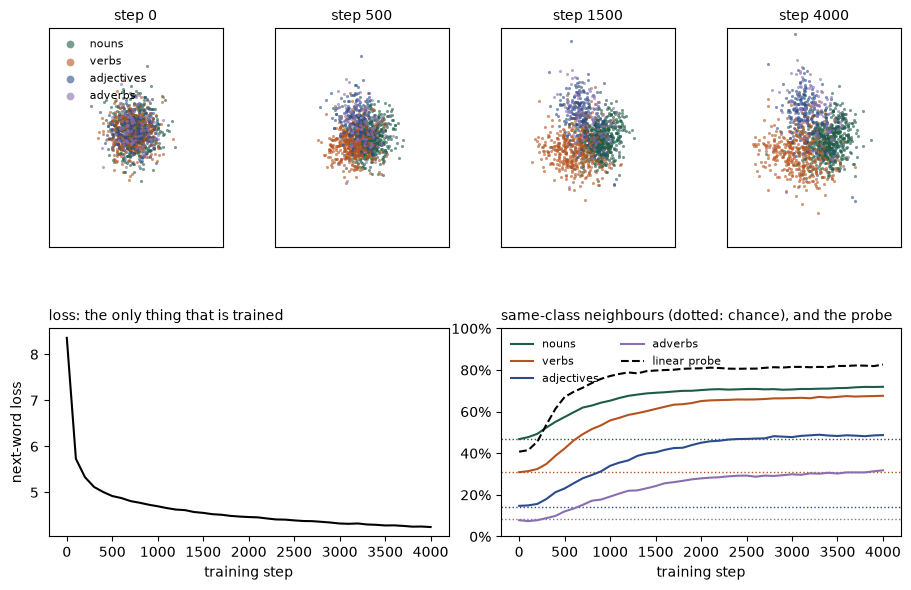

In [5]:
real, shuffled = viz.load("run_real.npz"), viz.load("run_shuffled.npz")
viz.fig_emergence(real)
plt.show()

## 4. The control: the same words, with the order destroyed

The shuffled model still learns something. Its loss goes down, because it can still learn which words are frequent
and which words share a sentence. But the two measures stay at chance.

                                    real text   shuffled   chance
loss after training                      4.25       5.45         
neighbours with the same class            64%        36%      34%
  nouns                                   72%        49%      47%
  verbs                                   68%        32%      31%
  adjectives                              49%        15%      14%
  adverbs                                 32%         9%       8%
linear probe                              83%        47%      47%


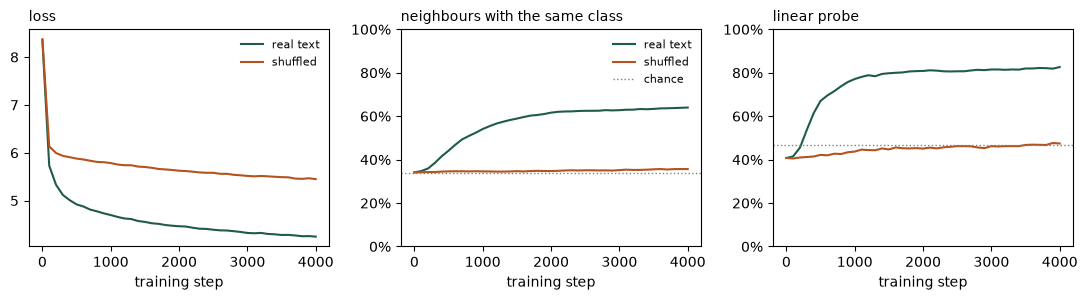

In [6]:
viz.summary(real, shuffled)
viz.fig_control(real, shuffled)
plt.show()

## 5. Nearest neighbours

Words that the model put near each other, after the full run. Change the list to try your own words. Most
neighbours have the same class as the word. They do not always have a similar meaning: the model is very small.

In [7]:
words = list(real["words"])
unit = real["final"] / np.linalg.norm(real["final"], axis=1, keepdims=True)

def neighbours(word, n=8):
    sim = unit @ unit[words.index(word)]
    return [words[i] for i in np.argsort(-sim)[1:n + 1]]

for word in ["house", "walked", "happy", "soon", "mother", "think"]:
    if word in words:
        print(f"{word:9s} {', '.join(neighbours(word))}")
    else:
        print(f"{word:9s} is not one of the {len(words):,} measured words")

house     wentworth, raised, come, pianoforte, park, spot, margaret, home
walked    moved, rose, drive, fell, written, quitted, stood, returned
happy     complete, excellent, sir, whole, private, immediate, spare, card
soon      easily, cousins, hours, game, scarcely, go, days, went
mother    harriet, school, hurry, sense, women, smiling, father, truth
think     consciousness, thought, aware, thinks, talked, wished, suppose, says


## 6. Change something

- `ae.FILES`: the texts. Any text of the NLTK Gutenberg collection works, for example `melville-moby_dick.txt`.
- `ae.DIM`: the size of the embeddings.
- The number of steps in section 2.

To repeat the full run and the control from a terminal (about 5 minutes each):

```
python attn_emergence.py 4000
python attn_emergence.py 4000 --shuffle
python viz_emergence.py
```

**About the numbers.** This code is a rebuild. The scripts of my first run were not kept, so I wrote the experiment
again from its description. All numbers and figures in the post come from this code.